In [1]:
pip install pandas numpy scikit-learn sentence-transformers networkx python-igraph leidenalg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 30.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 38.4 MB/s eta 0:00:00


In [2]:
from google.colab import files
uploads = files.upload()




In [2]:
import os
os.listdir()


['.config', 'dataset_with_topics .csv', 'sample_data']

In [3]:
import pandas as pd
df = pd.read_csv("dataset_with_topics .csv", sep = ";")
df.head()

,track_name,artist_name,danceability,energy,loudness,mode,key,speechiness,acousticness,instrumentalness,liveness,tempo,time_signature,duration_ms,source,lyrics,lyrics_missing,topic_number,topic_label
0,Wow.,Post Malone,833.0,539.0,-7.399,0,11,178.0000,163.0000,0.000002,101.0000,99.947,4,149520,spotify,"Said she tired of little money, need a big boy...",False,2.0,Boastful Rap Themes
1,"thank u, next",Ariana Grande,724.0,647.0,-5.642,1,1,0.0658,0.2800,0.000000,102.0000,106.960,4,207333,spotify,Thought I'd end up with Sean\nBut he wasn't a ...,False,0.0,Love & Life Themes
2,Without Me,Halsey,752.0,488.0,-7.050,1,6,0.0705,297.0000,0.000009,0.0936,136.041,4,201661,spotify,Found you when your heart was broke\nI filled ...,False,2.0,Boastful Rap Themes
3,Calma - Remix,"Pedro Capó, Farruko",826.0,773.0,-4.218,0,11,0.0524,323.0000,0.000000,143.0000,126.899,4,238200,spotify,Laramercy gang\nWelcome to the paradise\nFarru...,False,1.0,Desire & Emotions
4,Sweet but Psycho,Ava Max,719.0,704.0,-4.724,1,1,0.0476,0.0691,0.000000,166.0000,133.002,4,187436,spotify,"Oh, she's sweet but a psycho\nA little bit psy...",False,7.0,Nostalgia & Reflection


In [6]:
"""
Lyric Embedding Network Pipeline

Inputs
------
- CSV: dataset_with_topics.csv
  * columns: 'track_name' (song title), 'lyrics' (full text), plus any others you have

What this script does
---------------------
1) Loads and cleans the lyrics
2) Computes multilingual lyric embeddings (SentenceTransformers)
3) Builds a mutual k-nearest-neighbor (kNN) graph using cosine similarity as edge weights
4) Runs Leiden community detection on the weighted graph
5) Computes graph features (degree, strength, clustering, centrality)
6) Characterizes communities with top TF-IDF terms and exemplar songs
7) Saves tidy outputs for your regression / plots

Notes
-----
- Requires: pandas, numpy, scikit-learn, sentence-transformers, networkx, igraph, leidenalg
- If you prefer FAISS for speed on big data, you can swap the kNN step accordingly.
- This script is designed for clarity and rigor, not just quick demo.

"""

# ==========================
# 0. Configuration & Imports
# ==========================

import os
import math
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.neighbors import NearestNeighbors
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import networkx as nx

try:
    import igraph as ig
    import leidenalg as la
except Exception as e:
    raise RuntimeError(
        "This script requires 'python-igraph' and 'leidenalg'.\n"
        "Install with: pip install python-igraph leidenalg"
    )

try:
    from sentence_transformers import SentenceTransformer
except Exception as e:
    raise RuntimeError(
        "This script requires 'sentence-transformers'.\n"
        "Install with: pip install sentence-transformers"
    )

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

# Parameters you can tune
CSV_PATH = "dataset_with_topics.csv"
TEXT_COL = "lyrics"
TITLE_COL = "track_name"

EMBEDDING_MODEL = "paraphrase-multilingual-mpnet-base-v2"  # multilingual, 768-dim
K_NEIGHBORS = 15             # k for kNN graph
USE_MUTUAL_KNN = True        # keep edges only if mutual neighbors
MIN_SIM_THRESHOLD = 0.0      # optional global similarity floor (~0.35-0.45 is reasonable); 0 disables
MAX_NEIGHBORS_PER_NODE = None  # cap degree if needed (None = no cap)

# TF-IDF config (for community interpretation)
MAX_FEATURES_TFIDF = 30000
N_TOP_TERMS_PER_COMMUNITY = 15

# Output paths
OUT_DIR = "embedding_network_outputs"
EMBEDDINGS_NPY = os.path.join(OUT_DIR, "lyric_embeddings.npy")
NODES_CSV = os.path.join(OUT_DIR, "nodes_with_communities.csv")
EDGES_CSV = os.path.join(OUT_DIR, "edges_weighted.csv")
COMMUNITY_TERMS_CSV = os.path.join(OUT_DIR, "community_top_terms.csv")
COMMUNITY_EXEMPLARS_CSV = os.path.join(OUT_DIR, "community_exemplar_songs.csv")
GRAPHML_PATH = os.path.join(OUT_DIR, "lyric_similarity_graph.graphml")

os.makedirs(OUT_DIR, exist_ok=True)

# ======================
# 1. Load & Preprocess
# ======================


# Basic cleaning: drop missing lyrics
before = len(df)
df = df.dropna(subset=[TEXT_COL])
after = len(df)
print(f"Loaded {before} rows; kept {after} with non-null lyrics.")

# Optional: strip whitespace
df[TEXT_COL] = df[TEXT_COL].astype(str).str.replace("\n", " ").str.strip()

# ======================
# 2. Embeddings
# ======================

print("Loading embedding model...", EMBEDDING_MODEL)
model = SentenceTransformer(EMBEDDING_MODEL)

print("Encoding lyrics to embeddings (this may take a while)...")
embeddings = model.encode(
    df[TEXT_COL].tolist(),
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True  # cosine-friendly
)

np.save(EMBEDDINGS_NPY, embeddings)
print(f"Saved embeddings to {EMBEDDINGS_NPY}; shape={embeddings.shape}")

# ======================
# 3. kNN Graph Construction
# ======================

print("Fitting NearestNeighbors (cosine distance)...")
# cosine distance = 1 - cosine similarity
nn = NearestNeighbors(n_neighbors=K_NEIGHBORS + 1, metric='cosine')  # +1 includes self
nn.fit(embeddings)

# kneighbors returns distances (cosine distance) and indices
distances, indices = nn.kneighbors(embeddings)

# Convert to similarities
# First column is self (distance=0 -> sim=1), we'll drop it below
sims = 1 - distances

# Build edge list
rows = []
for i in range(len(df)):
    neigh_idx = indices[i][1:]  # drop self
    neigh_sim = sims[i][1:]

    for j, sim in zip(neigh_idx, neigh_sim):
        if MIN_SIM_THRESHOLD and sim < MIN_SIM_THRESHOLD:
            continue
        rows.append((i, j, float(sim)))

# Mutual kNN filtering (recommended)
if USE_MUTUAL_KNN:
    print("Applying mutual kNN filter...")
    # Build a quick lookup of neighbors
    neigh_sets = {i: set(indices[i][1:]) for i in range(len(df))}
    mutual_rows = []
    for i, j, w in rows:
        if i in neigh_sets.get(j, ()):  # mutual
            mutual_rows.append((i, j, w))
    rows = mutual_rows

# Optional: cap number of neighbors per node to avoid hubs
if MAX_NEIGHBORS_PER_NODE is not None:
    print(f"Capping neighbors per node at {MAX_NEIGHBORS_PER_NODE}...")
    by_i = {}
    for i, j, w in rows:
        by_i.setdefault(i, []).append((j, w))
    # keep top by weight
    capped_rows = []
    for i, lst in by_i.items():
        lst_sorted = sorted(lst, key=lambda x: -x[1])[:MAX_NEIGHBORS_PER_NODE]
        for j, w in lst_sorted:
            capped_rows.append((i, j, w))
    rows = capped_rows

# Deduplicate by keeping max weight for undirected edge
print("Building undirected weighted edge list...")
edge_dict = {}
for i, j, w in rows:
    a, b = sorted((i, j))
    if (a, b) not in edge_dict or w > edge_dict[(a, b)]:
        edge_dict[(a, b)] = w

edges = [(a, b, w) for (a, b), w in edge_dict.items()]

print(f"Graph edges (after processing): {len(edges)}")

# Save edges to CSV
edges_df = pd.DataFrame(edges, columns=["source_idx", "target_idx", "weight"])
edges_df.to_csv(EDGES_CSV, index=False)
print(f"Saved edges to {EDGES_CSV}")

# ======================
# 4. Build iGraph & Leiden
# ======================

print("Constructing igraph and running Leiden...")
# Create igraph (0..n-1 nodes)
g = ig.Graph()
g.add_vertices(len(df))
# add edges
edge_tuples = [(int(a), int(b)) for a, b, _ in edges]
g.add_edges(edge_tuples)
# set weights
g.es["weight"] = [float(w) for _, _, w in edges]

# Leiden partition (RBConfigurationVertexPartition is robust for weighted graphs)
partition = la.find_partition(
    g,
    la.RBConfigurationVertexPartition,
    weights=g.es["weight"],
    seed=RANDOM_STATE,
)

communities = np.array(partition.membership)
num_comms = len(set(communities))
print(f"Found {num_comms} communities via Leiden.")

# ======================
# 5. Graph Features (NetworkX for convenience)
# ======================

print("Computing graph features (degree, strength, centralities)...")
G = nx.Graph()
G.add_nodes_from(range(len(df)))
for a, b, w in edges:
    G.add_edge(int(a), int(b), weight=float(w))

# degree and strength
deg = dict(G.degree())
strength = {n: sum(d["weight"] for _, _, d in G.edges(n, data=True)) for n in G.nodes}

# Weighted clustering (using NetworkX approx)
clust = nx.clustering(G, weight='weight')

# Centrality (use weighted eigenvector; if it fails to converge, catch and fallback)
try:
    eig = nx.eigenvector_centrality(G, max_iter=1000, weight='weight')
except nx.PowerIterationFailedConvergence:
    eig = {n: np.nan for n in G.nodes}

# Betweenness can be expensive; sample if needed
bet = nx.betweenness_centrality(G, weight='weight', k=min(500, len(G))) if len(G) > 2000 else nx.betweenness_centrality(G, weight='weight')

# ======================
# 6. Node Table with Communities
# ======================

nodes_out = df.copy()
nodes_out["node_id"] = np.arange(len(df))
nodes_out["community"] = communities
nodes_out["degree"] = nodes_out["node_id"].map(deg)
nodes_out["strength"] = nodes_out["node_id"].map(strength)
nodes_out["eigenvector_centrality"] = nodes_out["node_id"].map(eig)
nodes_out["betweenness_centrality"] = nodes_out["node_id"].map(bet)

nodes_out.to_csv(NODES_CSV, index=False)
print(f"Saved nodes with communities and features to {NODES_CSV}")

# ======================
# 7. Community Interpretation (TF-IDF terms + exemplar songs)
# ======================

print("Computing TF-IDF top terms per community and exemplar songs...")
# Vectorize lyrics
vectorizer = TfidfVectorizer(
    max_features=MAX_FEATURES_TFIDF,
    lowercase=True,
    stop_words=None,  # consider custom multilingual stopwords if desired
    ngram_range=(1,2)
)
X = vectorizer.fit_transform(df[TEXT_COL].tolist())
terms = np.array(vectorizer.get_feature_names_out())

# For each community, compute average tf-idf score across its docs
comm_terms = []
comm_exemplars = []
for c in sorted(set(communities)):
    idx = np.where(communities == c)[0]
    if len(idx) == 0:
        continue
    Xc = X[idx]
    # mean tf-idf per term in community
    mean_scores = np.asarray(Xc.mean(axis=0)).ravel()
    top_idx = mean_scores.argsort()[::-1][:N_TOP_TERMS_PER_COMMUNITY]
    top_terms = terms[top_idx]
    top_scores = mean_scores[top_idx]

    for t, s in zip(top_terms, top_scores):
        comm_terms.append({"community": c, "term": t, "mean_tfidf": float(s)})

    # Exemplar songs: pick those with highest average similarity to others in the same community
    # Compute centroid in embedding space and rank by cosine to centroid
    centroid = embeddings[idx].mean(axis=0)
    centroid = centroid / (np.linalg.norm(centroid) + 1e-12)
    sims_to_centroid = (embeddings[idx] @ centroid)
    order = sims_to_centroid.argsort()[::-1]
    top_k = min(10, len(order))
    for r in range(top_k):
        song_i = idx[order[r]]
        comm_exemplars.append({
            "community": c,
            "rank": r+1,
            "node_id": int(song_i),
            "track_name": str(df.loc[song_i, TITLE_COL])
        })

pd.DataFrame(comm_terms).to_csv(COMMUNITY_TERMS_CSV, index=False)
pd.DataFrame(comm_exemplars).to_csv(COMMUNITY_EXEMPLARS_CSV, index=False)
print(f"Saved community top terms to {COMMUNITY_TERMS_CSV}")
print(f"Saved exemplar songs per community to {COMMUNITY_EXEMPLARS_CSV}")

# ======================
# 8. Save Graph (GraphML)
# ======================

print("Saving GraphML for Gephi/etc...")
# Attach node attributes
for col in [TITLE_COL]:
    g.vs[col] = df[col].astype(str).tolist()

g.vs["community"] = communities.tolist()
# Save as GraphML

# Convert igraph to networkx then write graphml for convenience
H = nx.Graph()
H.add_nodes_from(range(len(df)))
for n in H.nodes:
    H.nodes[n]["track_name"] = df.loc[n, TITLE_COL]
    H.nodes[n]["community"] = int(communities[n])
for a, b, w in edges:
    H.add_edge(int(a), int(b), weight=float(w))

nx.write_graphml(H, GRAPHML_PATH)
print(f"Saved GraphML to {GRAPHML_PATH}")

print("\nAll done! You now have:")
print(f"- {NODES_CSV}")
print(f"- {EDGES_CSV}")
print(f"- {COMMUNITY_TERMS_CSV}")
print(f"- {COMMUNITY_EXEMPLARS_CSV}")
print(f"- {GRAPHML_PATH}")

Loaded 3357 rows; kept 3357 with non-null lyrics.
Loading embedding model... paraphrase-multilingual-mpnet-base-v2


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Encoding lyrics to embeddings (this may take a while)...


Batches:   0%|          | 0/105 [00:00<?, ?it/s]

Saved embeddings to embedding_network_outputs/lyric_embeddings.npy; shape=(3357, 768)
Fitting NearestNeighbors (cosine distance)...
Applying mutual kNN filter...
Building undirected weighted edge list...
Graph edges (after processing): 6513
Saved edges to embedding_network_outputs/edges_weighted.csv
Constructing igraph and running Leiden...
Found 680 communities via Leiden.
Computing graph features (degree, strength, centralities)...
Saved nodes with communities and features to embedding_network_outputs/nodes_with_communities.csv
Computing TF-IDF top terms per community and exemplar songs...
Saved community top terms to embedding_network_outputs/community_top_terms.csv
Saved exemplar songs per community to embedding_network_outputs/community_exemplar_songs.csv
Saving GraphML for Gephi/etc...
Saved GraphML to embedding_network_outputs/lyric_similarity_graph.graphml

All done! You now have:
- embedding_network_outputs/nodes_with_communities.csv
- embedding_network_outputs/edges_weighted.

In [3]:
from google.colab import files

file_list = [
    "embedding_network_outputs/nodes_with_communities.csv",
    "embedding_network_outputs/edges_weighted.csv",
    "embedding_network_outputs/community_top_terms.csv",
    "embedding_network_outputs/community_exemplar_songs.csv",
    "embedding_network_outputs/lyric_similarity_graph.graphml"
]

for f in file_list:
    files.download(f)


FileNotFoundError: Cannot find file: embedding_network_outputs/nodes_with_communities.csv

In [5]:
from google.colab import files
uploads = files.upload()

Saving edges_weighted.csv to edges_weighted.csv


In [6]:
EDGES = "edges_weighted.csv"

In [7]:
from google.colab import files
uploads = files.upload()

Saving nodes_with_communities.csv to nodes_with_communities.csv


In [8]:
NODES = "nodes_with_communities.csv"

In [9]:
from google.colab import files
uploads = files.upload()

Saving community_top_terms.csv to community_top_terms.csv


In [10]:
COMM_TERMS = "community_top_terms.csv"

In [11]:
from google.colab import files
uploads = files.upload()

Saving community_exemplar_songs.csv to community_exemplar_songs.csv


In [12]:
COMM_EX = "community_exemplar_songs.csv"

In [14]:
import pandas as pd

# Paths from your pipeline
#NODES = "embedding_network_outputs/nodes_with_communities.csv"
#EDGES = "embedding_network_outputs/edges_weighted.csv"
#COMM_TERMS = "embedding_network_outputs/community_top_terms.csv"
#COMM_EX = "embedding_network_outputs/community_exemplar_songs.csv"

nodes = pd.read_csv(NODES)
edges = pd.read_csv(EDGES)
terms = pd.read_csv(COMM_TERMS)
exemplars = pd.read_csv(COMM_EX)

# Optional: if your original data had a 'source' column, it should be carried through.
# If not, comment the next line that uses 'source'.
has_source = "source" in nodes.columns

print(f"✅ Loaded: {len(nodes)} songs, {len(edges)} edges, {terms['community'].nunique()} communities with top terms.")


✅ Loaded: 3357 songs, 6513 edges, 680 communities with top terms.


In [15]:
# How many communities and their sizes
comm_sizes = nodes["community"].value_counts().sort_index()
print(f"Number of communities: {comm_sizes.index.nunique()}")
print("Community sizes:")
display(comm_sizes.to_frame("n_songs"))

# Top 10 biggest communities
print("\nTop 10 largest communities:")
display(comm_sizes.sort_values(ascending=False).head(10).to_frame("n_songs"))


Number of communities: 680
Community sizes:


,n_songs
community,
0,272
1,234
2,212
3,183
4,179
...,...
675,1
676,1
677,1



Top 10 largest communities:


,n_songs
community,
0,272
1,234
2,212
3,183
4,179
5,168
6,167
7,164
8,141


In [18]:
# Build a compact summary with size + central tendency of centralities
summary_cols = ["degree", "strength", "eigenvector_centrality", "betweenness_centrality"]
comm_summary = nodes.groupby("community")[summary_cols].agg(["mean","median"]).round(4)
comm_summary.insert(0, "n_songs", comm_sizes)
display(comm_summary.sort_values(("n_songs",""), ascending=False).head(15))


n_songs  degree        strength         eigenvector_centrality  \
                     mean median     mean  median                   mean   
community                                                                  
0             272  6.1581    6.0   4.6748  4.3789                 0.0007   
1             234  3.3590    3.0   2.3340  2.0005                 0.0000   
2             212  7.3302    7.0   5.7933  5.5061                 0.0025   
3             183  4.6066    4.0   3.4085  2.9370                 0.0001   
4             179  4.7039    4.0   3.5707  2.9731                 0.0002   
5             168  4.8095    4.0   3.5822  3.0612                 0.0001   
6             167  4.7006    4.0   3.4928  2.8498                 0.0020   
7             164  4.0366    3.0   2.9498  2.2050                 0.0002   
8             141  7.3475    7.0   5.8458  5.5980                 0.0412   
9             129  6.3643    6.0   5.0273  4.5455                 0.0067   
10            117  3.3675    3.0   2.3559  1.9248                 0.0000   
11            109  3.9725    3.0   2.9619  2.2396                 0.0002   
12            102  3.4608    3.0   2.4555  2.0652                 0.0000   
13             94  3.2021    3.0   2.3064  2.0591                 0.0003   
14             75  3.3467    3.0   2.3183  2.0670                 0.0001   

                  betweenness_centrality          
           median                   mean  median  
community                                         
0          0.0003                 0.0015  0.0010  
1          0.0000                 0.0016  0.0008  
2          0.0012                 0.0012  0.0010  
3          0.0000                 0.0016  0.0008  
4          0.0001                 0.0013  0.0008  
5          0.0000                 0.0014  0.0007  
6          0.0001                 0.0014  0.0007  
7          0.0000                 0.0016  0.0008  
8          0.0085                 0.0013  0.0008  
9          0.0020                 0.0011  0.0006  
10         0.0000                 0.0016  0.0007  
11         0.0000                 0.0012  0.0005  
12         0.0000                 0.0012  0.0005  
13         0.0000                 0.0014  0.0005  
14         0.0000                 0.0009  0.0004

In [19]:
# Top terms per community (first 10)
def top_terms_for_community(c, k=10):
    t = terms[terms["community"] == c].sort_values("mean_tfidf", ascending=False).head(k)
    return list(t["term"])

quick_terms = (
    terms.sort_values(["community","mean_tfidf"], ascending=[True, False])
         .groupby("community")
         .head(10)[["community","term"]]
)

print("Top 10 terms per community:")
display(quick_terms.head(100))  # shows first 10 communities' terms; increase if you want more


Top 10 terms per community:


,community,term
0,0,the
1,0,you
2,0,it
3,0,my
4,0,yeah
...,...,...
140,9,te
141,9,oh
142,9,tú
143,9,yo


In [20]:
# Show top 3 exemplars per community (track names)
ex3 = (exemplars.sort_values(["community","rank"])
                .groupby("community")
                .head(3)[["community","rank","track_name"]])
print("Top 3 exemplar songs per community:")
display(ex3.head(60))  # expands as needed


Top 3 exemplar songs per community:


,community,rank,track_name
0,0,1,Did It Again
1,0,2,Yikes
2,0,3,"Numbers (feat. Roddy Ricch, Gunna and London O..."
10,1,1,Supalonely (feat. Gus Dapperton)
11,1,2,Supalonely
12,1,3,Fly To My Room
20,2,1,PORFA
21,2,2,"Nicki Nicole: Bzrp Music Sessions, Vol. 13"
22,2,3,Bubalu
30,3,1,IDGAF


In [21]:
# Top songs by eigenvector centrality (influential in lyric space)
cols = ["track_name","community","degree","strength","eigenvector_centrality","betweenness_centrality"]
if has_source: cols.insert(1, "source")

print("Top 15 by eigenvector centrality:")
display(nodes.sort_values("eigenvector_centrality", ascending=False)[cols].head(15))

print("\nTop 15 by betweenness centrality (bridges across themes):")
display(nodes.sort_values("betweenness_centrality", ascending=False)[cols].head(15))


Top 15 by eigenvector centrality:


,track_name,source,community,degree,strength,eigenvector_centrality,betweenness_centrality
2322,Fiel - Remix,spotify,8,15,12.709632,0.292668,0.000060
432,Que Mas Pues - Remix,spotify,8,14,11.807117,0.276110,0.000030
551,Rebota - Remix,spotify,8,14,11.666897,0.263342,0.000128
2314,Poblado - Remix,spotify,8,14,11.458150,0.248413,0.000037
1618,"PORFA Remix ( Feat. Maluma, Nicky Jam, Sech) -...",spotify,8,12,9.977599,0.237934,0.000196
488,Hasta Que Salga el Sol,spotify,8,14,11.309590,0.233634,0.000508
2283,No Te Enamores - Remix,spotify,8,15,12.522739,0.224004,0.000413
2141,Arcoíris,spotify,8,14,11.299496,0.222577,0.000278
986,"Cayó La Noche (feat. Cruz Cafuné, Abhir Hathi,...",spotify,8,12,9.939202,0.212810,0.000085
320,"DJ No Pare (feat. Zion, Dalex, Lenny Tavárez) ...",spotify,8,14,11.310083,0.210915,0.002973



Top 15 by betweenness centrality (bridges across themes):


,track_name,source,community,degree,strength,eigenvector_centrality,betweenness_centrality
3030,BANG BANG BANG,tiktok,1,11,8.021749,0.000080,0.022023
2050,WANNABE,spotify,1,12,8.719261,0.000043,0.018253
1084,Godzilla (feat. Juice WRLD),spotify,7,12,9.139335,0.000532,0.015747
347,Baby (Lil Baby feat. DaBaby),spotify,10,10,7.205822,0.000213,0.013946
1668,XXL,spotify,13,8,6.058367,0.001263,0.013268
194,Sucker,spotify,12,9,6.778358,0.001386,0.012991
1744,Blastoff (feat. Juice Wrld & Trippie Redd),spotify,10,11,8.083655,0.000270,0.012570
2511,malibu,spotify,8,15,12.010823,0.012948,0.012534
221,Mixed Personalities (feat. Kanye West),spotify,11,10,7.194582,0.000011,0.012342
1640,DOLLAZ ON MY HEAD (feat. Young Thug),spotify,10,10,7.073482,0.000020,0.012004


In [22]:
def report_community(c, k_terms=10, k_ex=5):
    size = (nodes["community"] == c).sum()
    print(f"=== Community {c} | size={size} ===")

    # Top terms
    tt = terms[terms["community"] == c].sort_values("mean_tfidf", ascending=False).head(k_terms)
    print("Top terms:", ", ".join(tt["term"].tolist()))

    # Exemplars
    ex = exemplars[exemplars["community"] == c].sort_values("rank").head(k_ex)
    print("Exemplar songs:")
    for _, row in ex.iterrows():
        print(f"  #{row['rank']}: {row['track_name']}")

    # Centrality stats
    subset = nodes[nodes["community"] == c]
    for metric in ["degree","strength","eigenvector_centrality","betweenness_centrality"]:
        print(f"{metric}: mean={subset[metric].mean():.3f}, median={subset[metric].median():.3f}")

    # Source mix
    if has_source:
        mix = subset["source"].value_counts(normalize=True).mul(100).round(1).to_dict()
        print("Source mix (%):", mix)

# Example:
report_community(0)


=== Community 0 | size=272 ===
Top terms: the, you, it, my, yeah, on, bitch, nigga, up, that
Exemplar songs:
  #1: Did It Again
  #2: Yikes
  #3: Numbers (feat. Roddy Ricch, Gunna and London On Da Track)
  #4: Praise The Lord (Da Shine) (feat. Skepta)
  #5: Thot Shit
degree: mean=6.158, median=6.000
strength: mean=4.675, median=4.379
eigenvector_centrality: mean=0.001, median=0.000
betweenness_centrality: mean=0.001, median=0.001
Source mix (%): {'spotify': 75.7, 'tiktok': 24.3}


✅ Proposed analysis pipeline (recommended)
✅ Step 1: Identify top N communities

Find communities that cover ~70% of your dataset.
Often N ~ 10–15.

✅ Step 2: Label these communities

Use:

top TF-IDF terms

exemplar songs

✅ Step 3: Compare TikTok vs Spotify distribution

Across these major communities.

In [23]:
#Step 1: Identifying major communities

import pandas as pd

# Count community sizes
comm_sizes = nodes["community"].value_counts().sort_values(ascending=False)

# Compute cumulative coverage
cum = comm_sizes.cumsum() / comm_sizes.sum()

# Select communities covering ~70% of data
major_comms = cum[cum <= 0.70].index.tolist()

print(f"✅ Found {len(major_comms)} major communities covering ~70% of the dataset.")
print("Major communities:", major_comms)

# Create a table for inspection
coverage_table = pd.DataFrame({
    "community": comm_sizes.index,
    "size": comm_sizes.values,
    "cumulative_pct": cum.values.round(3)
})

display(coverage_table.head(20))


✅ Found 15 major communities covering ~70% of the dataset.
Major communities: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]


,community,size,cumulative_pct
0,0,272,0.081
1,1,234,0.151
2,2,212,0.214
3,3,183,0.268
4,4,179,0.322
5,5,168,0.372
6,6,167,0.422
7,7,164,0.470
8,8,141,0.512
9,9,129,0.551


In [24]:
#Step 2: Label major communities using top terms and representative songs

def label_community(c, n_terms=10, n_songs=5):
    print(f"\n=== COMMUNITY {c} ===")

    # size
    size = comm_sizes.loc[c]
    print(f"Size: {size} songs")

    # top terms
    print("\nTop terms:")
    t = (terms[terms["community"] == c]
         .sort_values("mean_tfidf", ascending=False)
         .head(n_terms))
    print(", ".join(t["term"].tolist()))

    # exemplars
    print("\nRepresentative songs:")
    e = (exemplars[exemplars["community"] == c]
         .sort_values("rank")
         .head(n_songs))
    for _, row in e.iterrows():
        print(f"  #{row['rank']}: {row['track_name']}")


In [25]:
for c in major_comms:
    label_community(c)



=== COMMUNITY 0 ===
Size: 272 songs

Top terms:
the, you, it, my, yeah, on, bitch, nigga, up, that

Representative songs:
  #1: Did It Again
  #2: Yikes
  #3: Numbers (feat. Roddy Ricch, Gunna and London On Da Track)
  #4: Praise The Lord (Da Shine) (feat. Skepta)
  #5: Thot Shit

=== COMMUNITY 1 ===
Size: 234 songs

Top terms:
you, the, my, to, it, and, me, oh, yeah, that

Representative songs:
  #1: Supalonely (feat. Gus Dapperton)
  #2: Supalonely
  #3: Fly To My Room
  #4: Into Your Arms (feat. Ava Max)
  #5: You Never Know

=== COMMUNITY 2 ===
Size: 212 songs

Top terms:
que, te, you, la, no, me, de, yo, tú, oh

Representative songs:
  #1: PORFA
  #2: Nicki Nicole: Bzrp Music Sessions, Vol. 13
  #3: Bubalu
  #4: Calling My Phone
  #5: Oh Na Na

=== COMMUNITY 3 ===
Size: 183 songs

Top terms:
you, it, me, the, and, oh, to, that, my, re

Representative songs:
  #1: IDGAF
  #2: Race My Mind
  #3: You’re Not Sorry (Taylor’s Version)
  #4: Grow A Pear
  #5: Mean It

=== COMMUNITY 4 ==

In [26]:
import pandas as pd

# Create the mapping dictionary based on your summary table
community_labels = {
    0: {
        "label_short": "Hype Rap / Flex",
        "label_long": "Aggressive hype rap with braggadocio and explicit language.",
        "category": "Rap / Trap"
    },
    1: {
        "label_short": "Mainstream Pop",
        "label_long": "Mainstream English pop with general emotional themes.",
        "category": "Pop"
    },
    2: {
        "label_short": "Latin Pop (Emotional)",
        "label_long": "Emotional Spanish-language reggaeton and urbano pop.",
        "category": "Latin / Urbano"
    },
    3: {
        "label_short": "Sad Pop / Breakup",
        "label_long": "English pop focused on heartbreak and emotional conflict.",
        "category": "Pop"
    },
    4: {
        "label_short": "Romantic Ballads",
        "label_long": "Slow, emotional ballads about love and longing.",
        "category": "Pop / Ballad"
    },
    5: {
        "label_short": "Soft Pop / Love",
        "label_long": "Gentle pop love songs with occasional Spanish crossover.",
        "category": "Pop"
    },
    6: {
        "label_short": "Latin Trap / Urbano",
        "label_long": "High-energy urbano and Latin trap tracks.",
        "category": "Latin / Urbano"
    },
    7: {
        "label_short": "Global Trap / Hype",
        "label_long": "High-energy multilingual trap with global influences.",
        "category": "Rap / Trap"
    },
    8: {
        "label_short": "Latin Dance / Reggaeton",
        "label_long": "Dance-oriented reggaeton and urbano tracks.",
        "category": "Latin / Urbano"
    },
    9: {
        "label_short": "Romantic Reggaeton / Party",
        "label_long": "Romantic reggaeton with strong dance/party elements.",
        "category": "Latin / Urbano"
    },
    10: {
        "label_short": "Melodic Trap",
        "label_long": "Melodic trap featuring emotional lyrics and rap vocals.",
        "category": "Rap / Trap"
    },
    11: {
        "label_short": "Pop-R&B (Sensual)",
        "label_long": "Smooth sensual R&B-influenced pop songs.",
        "category": "Pop / R&B"
    },
    12: {
        "label_short": "Alternative / Atmospheric Pop",
        "label_long": "Dreamy, atmospheric alternative pop.",
        "category": "Alt Pop"
    },
    13: {
        "label_short": "Chant / Hook Pop",
        "label_long": "Hook-driven pop built around repetitive vocal syllables.",
        "category": "Pop"
    },
    14: {
        "label_short": "Emo Rap / Melodic Hip-Hop",
        "label_long": "Emotional rap with melodic elements and relationship themes.",
        "category": "Rap / Trap"
    }
}

# Convert to DataFrame
label_df = pd.DataFrame.from_dict(community_labels, orient="index")
label_df.index.name = "community"
label_df.reset_index(inplace=True)

print("✅ Community label mapping created!")
display(label_df)


✅ Community label mapping created!


,community,label_short,label_long,category
0,0,Hype Rap / Flex,Aggressive hype rap with braggadocio and expli...,Rap / Trap
1,1,Mainstream Pop,Mainstream English pop with general emotional ...,Pop
2,2,Latin Pop (Emotional),Emotional Spanish-language reggaeton and urban...,Latin / Urbano
3,3,Sad Pop / Breakup,English pop focused on heartbreak and emotiona...,Pop
4,4,Romantic Ballads,"Slow, emotional ballads about love and longing.",Pop / Ballad
5,5,Soft Pop / Love,Gentle pop love songs with occasional Spanish ...,Pop
6,6,Latin Trap / Urbano,High-energy urbano and Latin trap tracks.,Latin / Urbano
7,7,Global Trap / Hype,High-energy multilingual trap with global infl...,Rap / Trap
8,8,Latin Dance / Reggaeton,Dance-oriented reggaeton and urbano tracks.,Latin / Urbano
9,9,Romantic Reggaeton / Party,Romantic reggaeton with strong dance/party ele...,Latin / Urbano


In [27]:
from google.colab import files
uploads = files.upload()

Saving dataset_with_topics .csv to dataset_with_topics .csv


In [30]:
# === Option B: Keep all songs, label major communities, set all others to "Other" ===
import pandas as pd
import os

# -----------------------
# Config: choose ONE mode
# -----------------------
# Mode 1: pick top N communities by size (recommended)
USE_TOP_N = True
TOP_N = 15

# Mode 2: cover ~X% of the dataset (set USE_TOP_N = False to use this)
COVERAGE_TARGET = 0.70

# Input paths
NODES = "nodes_with_communities.csv"
ORIG_A = "dataset_with_topics .csv"        # preferred
ORIG_B = "dataset_with_topics.csv"     # fallback if ORIG_A not found

# Output path
OUT = "data_with_topics_and_communities.csv"

# --------------------------------
# 1) Load data (with graceful fallbacks)
# --------------------------------
nodes = pd.read_csv(NODES)

if os.path.exists(ORIG_A):
    df = pd.read_csv(ORIG_A, sep = ";")
    print(f"Loaded original dataset from {ORIG_A} ({len(df)} rows).")
elif os.path.exists(ORIG_B):
    df = pd.read_csv(ORIG_B)
    print(f"Loaded original dataset from {ORIG_B} ({len(df)} rows).")
else:
    raise FileNotFoundError("Could not find data_with_topics.csv or dataset_with_topics.csv in the working directory.")

# Ensure required columns exist
if "track_name" not in df.columns:
    raise KeyError("Your original dataset must contain a 'track_name' column.")
if "track_name" not in nodes.columns or "community" not in nodes.columns:
    raise KeyError("nodes_with_communities.csv must contain 'track_name' and 'community' columns.")

# --------------------------------
# 2) Identify major communities
# --------------------------------
comm_sizes = nodes["community"].value_counts().sort_values(ascending=False)

if USE_TOP_N:
    major_comms = comm_sizes.head(TOP_N).index.tolist()
else:
    cum = (comm_sizes.cumsum() / comm_sizes.sum())
    major_comms = cum[cum <= COVERAGE_TARGET].index.tolist()

print(f"Major communities detected: {len(major_comms)} → {major_comms[:20]}{' ...' if len(major_comms)>20 else ''}")
print(f"Coverage by majors: {comm_sizes.loc[major_comms].sum()} / {len(nodes)} songs "
      f"({comm_sizes.loc[major_comms].sum()/len(nodes)*100:.1f}%)")

# --------------------------------
# 3) Labels for your 15 interpreted communities (as provided)
#    NOTE: These IDs match your earlier summaries for communities 0..14.
#    If a major community outside 0..14 appears, we’ll give it a generic label.
# --------------------------------
community_labels = {
    0:  {"label_short":"Hype Rap / Flex","label_long":"Aggressive hype rap with braggadocio and explicit language.","category":"Rap / Trap"},
    1:  {"label_short":"Mainstream Pop","label_long":"Mainstream English pop with general emotional themes.","category":"Pop"},
    2:  {"label_short":"Latin Pop (Emotional)","label_long":"Emotional Spanish-language reggaeton and urbano pop.","category":"Latin / Urbano"},
    3:  {"label_short":"Sad Pop / Breakup","label_long":"English pop focused on heartbreak and emotional conflict.","category":"Pop"},
    4:  {"label_short":"Romantic Ballads","label_long":"Slow, emotional ballads about love and longing.","category":"Pop / Ballad"},
    5:  {"label_short":"Soft Pop / Love","label_long":"Gentle pop love songs with occasional Spanish crossover.","category":"Pop"},
    6:  {"label_short":"Latin Trap / Urbano","label_long":"High-energy urbano and Latin trap tracks.","category":"Latin / Urbano"},
    7:  {"label_short":"Global Trap / Hype","label_long":"High-energy multilingual trap with global influences.","category":"Rap / Trap"},
    8:  {"label_short":"Latin Dance / Reggaeton","label_long":"Dance-oriented reggaeton and urbano tracks.","category":"Latin / Urbano"},
    9:  {"label_short":"Romantic Reggaeton / Party","label_long":"Romantic reggaeton with strong dance/party elements.","category":"Latin / Urbano"},
    10: {"label_short":"Melodic Trap","label_long":"Melodic trap featuring emotional lyrics and rap vocals.","category":"Rap / Trap"},
    11: {"label_short":"Pop-R&B (Sensual)","label_long":"Smooth sensual R&B-influenced pop songs.","category":"Pop / R&B"},
    12: {"label_short":"Alternative / Atmospheric Pop","label_long":"Dreamy, atmospheric alternative pop.","category":"Alt Pop"},
    13: {"label_short":"Chant / Hook Pop","label_long":"Hook-driven pop built around repetitive vocal syllables.","category":"Pop"},
    14: {"label_short":"Emo Rap / Melodic Hip-Hop","label_long":"Emotional rap with melodic elements and relationship themes.","category":"Rap / Trap"},
}

label_df = pd.DataFrame.from_dict(community_labels, orient="index")
label_df.index.name = "community"
label_df = label_df.reset_index()

# --------------------------------
# 4) Build a “simplified” label table: majors keep IDs+labels, others → "Other"
# --------------------------------
majors_df = label_df[label_df["community"].isin(major_comms)].copy()

# For any major community not in the manual mapping (rare), assign a generic label
missing_labeled = sorted(set(major_comms) - set(majors_df["community"]))
if missing_labeled:
    print(f"Note: {len(missing_labeled)} major community(ies) had no manual label; assigning generic names: {missing_labeled}")
    majors_df = pd.concat([
        majors_df,
        pd.DataFrame({
            "community": missing_labeled,
            "label_short": [f"Major c{c}" for c in missing_labeled],
            "label_long":  [f"Large community {c} (no manual label)"]*len(missing_labeled),
            "category":    ["Unlabeled"]*len(missing_labeled),
        })
    ], ignore_index=True)

# Build a full mapping table that includes “Other” as a catch-all
# We'll merge major labels by community; non-majors will be NaN then filled with “Other”
label_cols = ["label_short","label_long","category"]

# --------------------------------
# 5) Merge into the original dataset (keep ALL columns)
# --------------------------------
merged = df.merge(nodes[["track_name","community"]], on="track_name", how="left")

# Add readable simplified columns
merged = merged.merge(majors_df, on="community", how="left")

# Everything not in majors → "Other"
merged["community_simplified"] = merged["community"].where(merged["community"].isin(major_comms), "Other")
merged["label_short_simplified"] = merged["label_short"].fillna("Other")
merged["label_long_simplified"]  = merged["label_long"].fillna("Other")
merged["category_simplified"]    = merged["category"].fillna("Other")

# --------------------------------
# 6) Save + quick sanity checks
# --------------------------------
merged.to_csv(OUT, index=False)
print(f"\n✅ Saved: {OUT}")
print(f"Rows: {len(merged)} | Columns: {len(merged.columns)}")

# Coverage check
covered = (merged["community_simplified"] != "Other").mean()*100
print(f"Coverage by major communities in merged dataset: {covered:.1f}%")

# Peek
cols_show = ["track_name","community","community_simplified","label_short_simplified","category_simplified"]
print("\nPreview:")
display(merged[cols_show].head(10))

# Counts by simplified label (nice to inspect)
print("\nCounts by simplified label_short:")
display(merged["label_short_simplified"].value_counts().to_frame("count"))


Loaded original dataset from dataset_with_topics .csv (3357 rows).
Major communities detected: 15 → [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
Coverage by majors: 2346 / 3357 songs (69.9%)

✅ Saved: data_with_topics_and_communities.csv
Rows: 3613 | Columns: 27
Coverage by major communities in merged dataset: 70.1%

Preview:


,track_name,community,community_simplified,label_short_simplified,category_simplified
0,Wow.,0,0,Hype Rap / Flex,Rap / Trap
1,"thank u, next",96,Other,Other,Other
2,Without Me,5,5,Soft Pop / Love,Pop
3,Without Me,231,Other,Other,Other
4,Calma - Remix,97,Other,Other,Other
5,Sweet but Psycho,6,6,Latin Trap / Urbano,Latin / Urbano
6,Dancing With A Stranger (with Normani),4,4,Romantic Ballads,Pop / Ballad
7,High Hopes,82,Other,Other,Other
8,MIA (feat. Drake),98,Other,Other,Other
9,Happier,3,3,Sad Pop / Breakup,Pop



Counts by simplified label_short:


,count
label_short_simplified,
Other,1082
Hype Rap / Flex,298
Mainstream Pop,251
Latin Pop (Emotional),231
Sad Pop / Breakup,192
Romantic Ballads,191
Latin Trap / Urbano,188
Soft Pop / Love,181
Global Trap / Hype,176


so this is our result:
| Community | Proposed Label                | Core Language   | Stylistic Theme         |
| --------- | ----------------------------- | --------------- | ----------------------- |
| 0         | Hype Rap / Flex               | English         | aggressive, braggadocio |
| 1         | Mainstream Pop                | English         | general pop             |
| 2         | Latin Pop (Emotional)         | Spanish         | emotional urbano        |
| 3         | Sad Pop / Breakup             | English         | heartbreak              |
| 4         | Romantic Ballads              | English         | soft love ballads       |
| 5         | Soft Pop / Love               | English/Spanish | gentle love pop         |
| 6         | Latin Trap / Urbano           | Spanish         | upbeat urbano           |
| 7         | Global Trap / Hype            | multilingual    | viral trap              |
| 8         | Latin Dance / Reggaeton       | Spanish         | dance reggaeton         |
| 9         | Romantic Reggaeton / Party    | Spanish         | dance & romance         |
| 10        | Melodic Trap                  | English         | melodic rap             |
| 11        | Pop-R&B (Sensual)             | English         | sensual R&B             |
| 12        | Alternative / Atmospheric Pop | English         | dreamy pop              |
| 13        | Chant / Hook Pop              | mixed           | repetitive hooks        |
| 14        | Emo Rap / Melodic Hip-Hop     | English         | emotional rap           |


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [32]:
#step 3: compare tiktok and spotify and cross-over

# Make sure 'merged' is the dataset created earlier
df = merged.copy()

# Count platforms per track_name
platform_counts = df.groupby("track_name")["source"].nunique()

# Create a mapping for track_name → type
track_type_map = platform_counts.map(
    lambda x: "cross" if x > 1 else None
)

# If a track appears only once, determine its source
for name in track_type_map.index:
    if track_type_map[name] is None:
        source = df.loc[df["track_name"] == name, "source"].iloc[0]
        track_type_map[name] = source

# Add to df
df["track_type"] = df["track_name"].map(track_type_map)

df["track_type"].value_counts()


,count
track_type,
spotify,2786
tiktok,441
cross,386


In [33]:
# Distribution of platforms within communities
table = pd.crosstab(df["label_short_simplified"], df["track_type"], normalize="index") * 100
table = table.round(1)

display(table)


track_type,cross,spotify,tiktok
label_short_simplified,,,
Alternative / Atmospheric Pop,13.8,73.3,12.9
Chant / Hook Pop,11.9,75.2,12.9
Emo Rap / Melodic Hip-Hop,0.0,82.7,17.3
Global Trap / Hype,11.4,79.5,9.1
Hype Rap / Flex,13.8,67.8,18.5
Latin Dance / Reggaeton,6.1,93.2,0.7
Latin Pop (Emotional),9.5,84.4,6.1
Latin Trap / Urbano,20.2,69.1,10.6
Mainstream Pop,12.0,78.9,9.2


In [34]:
#for just tiktok vs spotify comparison
platform_specific = df[df["track_type"].isin(["tiktok","spotify"])]

pd.crosstab(
    platform_specific["label_short_simplified"],
    platform_specific["track_type"],
    normalize="index"
).round(2)


track_type,spotify,tiktok
label_short_simplified,,
Alternative / Atmospheric Pop,0.85,0.15
Chant / Hook Pop,0.85,0.15
Emo Rap / Melodic Hip-Hop,0.83,0.17
Global Trap / Hype,0.90,0.10
Hype Rap / Flex,0.79,0.21
Latin Dance / Reggaeton,0.99,0.01
Latin Pop (Emotional),0.93,0.07
Latin Trap / Urbano,0.87,0.13
Mainstream Pop,0.90,0.10


In [35]:
#identify which communities have the most crossover songs

cross_dist = df[df["track_type"]=="cross"]["label_short_simplified"].value_counts(normalize=True)*100
cross_dist.round(1)


,proportion
label_short_simplified,
Other,26.7
Hype Rap / Flex,10.6
Latin Trap / Urbano,9.8
Mainstream Pop,7.8
Romantic Reggaeton / Party,6.5
Latin Pop (Emotional),5.7
Global Trap / Hype,5.2
Pop-R&B (Sensual),4.1
Alternative / Atmospheric Pop,4.1


<Axes: xlabel='track_type', ylabel='label_short_simplified'>

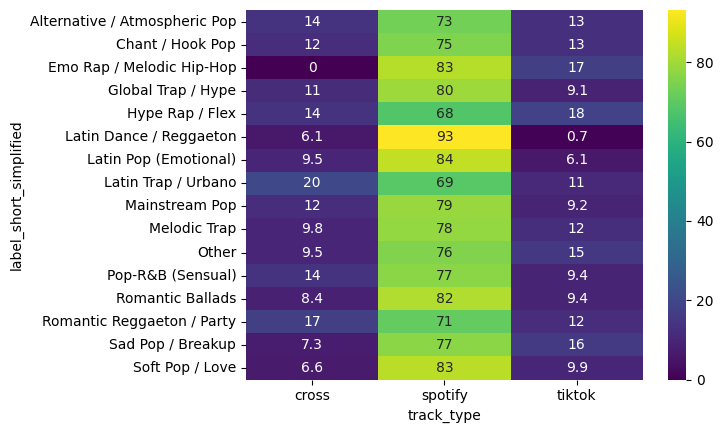

In [36]:
import seaborn as sns
sns.heatmap(table, annot=True, cmap="viridis")


In [44]:
import pandas as pd

IN_PATH  = "data_with_topics_and_communities.csv"
OUT_PATH = "data_with_topics_communities_crossover.csv"

# 1) Load
df = pd.read_csv(IN_PATH)

# 2) Basic checks
required = {"track_name", "source"}
missing = required - set(df.columns)
if missing:
    raise KeyError(f"Missing required column(s): {missing}. Expected at least {required} in {IN_PATH}")

# 3) Normalize source text
df["source_norm"] = (
    df["source"]
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({"tik tok": "tiktok", "ticktock":"tiktok"})  # optional cleanup
)

# 4) Build song-level platform sets
platform_sets = (
    df.groupby("track_name")["source_norm"]
      .apply(lambda s: sorted(set([x for x in s.dropna() if x in {"tiktok","spotify"}])))
)

# 5) Map to track_type
def to_track_type(src_list):
    if len(src_list) == 2:
        return "cross"
    if len(src_list) == 1:
        return src_list[0]  # "tiktok" or "spotify"
    return None

track_type_map = platform_sets.map(to_track_type).to_dict()

# 6) Add columns back to every row
df["track_type"] = df["track_name"].map(track_type_map)
df["is_cross"]   = (df["track_type"] == "cross")

# 7) (Optional) quick sanity checks
print("Counts by track_type:")
print(df["track_type"].value_counts(dropna=False))

print("\nDistinct songs by type:")
print(df.drop_duplicates("track_name")["track_type"].value_counts(dropna=False))

# 8) Save
# drop helper column if you like
df_out = df.drop(columns=["source_norm"])
df_out.to_csv(OUT_PATH, index=False)
print(f"\n✅ Saved with crossover columns → {OUT_PATH}")


Counts by track_type:
track_type
spotify    2786
tiktok      441
cross       386
Name: count, dtype: int64

Distinct songs by type:
track_type
spotify    2706
tiktok      432
cross        94
Name: count, dtype: int64

✅ Saved with crossover columns → data_with_topics_communities_crossover.csv


In [45]:
from google.colab import files
files.download("data_with_topics_communities_crossover.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>